# Benchmark: all methods in `bensemble`

Этот ноутбук делает единый бенчмарк по методам из репозитория:

- **LaplaceApproximation** (classification + regression)
- **ProbabilisticBackpropagation** (regression)
- **MC Dropout** (`MCDropoutEnsembler`)
- **NES-RS** (`RandomSearcher`)
- **NES-RE** (`EvolutionarySearcher`)
- **NESBS** (`NESBayesianSampler`: `sample_mc` и `sample_svgd`)

> Запускайте ячейки сверху вниз. В конце будут таблицы и графики сравнения.


In [3]:
import random
import time
from dataclasses import dataclass

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons, make_regression
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from torch.utils.data import DataLoader, TensorDataset

from bensemble.core.ensemble import Ensemble
from bensemble.methods import LaplaceApproximation, ProbabilisticBackpropagation
from bensemble.diversity.dropout import MCDropoutEnsembler
from bensemble.search import (
    SearchSpace,
    RandomSearcher,
    EvolutionarySearcher,
    NESBayesianSampler,
)

SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


Device: cpu


In [4]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


@dataclass
class RunCfg:
    fast: bool = True
    cls_train_epochs: int = 20
    reg_train_epochs: int = 24
    pool_size: int = 10
    ensemble_size: int = 4


cfg = RunCfg(fast=True)
if cfg.fast:
    cfg.cls_train_epochs = 12
    cfg.reg_train_epochs = 16
    cfg.pool_size = 8
    cfg.ensemble_size = 3

print(cfg)


RunCfg(fast=True, cls_train_epochs=12, reg_train_epochs=16, pool_size=8, ensemble_size=3)


In [5]:
# --- Data builders ---
def make_classification_loaders(seed=SEED):
    X, y = make_moons(n_samples=1600, noise=0.30, random_state=seed)
    X = StandardScaler().fit_transform(X)

    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.4, random_state=seed, stratify=y
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, random_state=seed, stratify=y_temp
    )

    def to_loader(X_np, y_np, bs=64, shuffle=False):
        xt = torch.tensor(X_np, dtype=torch.float32)
        yt = torch.tensor(y_np, dtype=torch.long)
        return DataLoader(TensorDataset(xt, yt), batch_size=bs, shuffle=shuffle)

    return {
        "train_loader": to_loader(X_train, y_train, bs=64, shuffle=True),
        "val_loader": to_loader(X_val, y_val, bs=128, shuffle=False),
        "test_loader": to_loader(X_test, y_test, bs=128, shuffle=False),
        "X_test": torch.tensor(X_test, dtype=torch.float32),
        "y_test": torch.tensor(y_test, dtype=torch.long),
    }


def make_regression_loaders(seed=SEED):
    X, y = make_regression(
        n_samples=1400,
        n_features=8,
        n_informative=8,
        noise=12.0,
        random_state=seed,
    )
    y = y.reshape(-1, 1)

    X = StandardScaler().fit_transform(X)
    y = StandardScaler().fit_transform(y)

    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.4, random_state=seed
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, random_state=seed
    )

    def to_loader(X_np, y_np, bs=64, shuffle=False):
        xt = torch.tensor(X_np, dtype=torch.float32)
        yt = torch.tensor(y_np, dtype=torch.float32)
        return DataLoader(TensorDataset(xt, yt), batch_size=bs, shuffle=shuffle)

    return {
        "train_loader": to_loader(X_train, y_train, bs=64, shuffle=True),
        "val_loader": to_loader(X_val, y_val, bs=128, shuffle=False),
        "test_loader": to_loader(X_test, y_test, bs=128, shuffle=False),
        "X_test": torch.tensor(X_test, dtype=torch.float32),
        "y_test": torch.tensor(y_test, dtype=torch.float32),
    }

cls_data = make_classification_loaders()
reg_data = make_regression_loaders()
print("Classification test size:", len(cls_data["X_test"]))
print("Regression test size:", len(reg_data["X_test"]))


Classification test size: 320
Regression test size: 280


In [6]:
# --- Models and training helpers ---
def build_cls_model(hidden=32, depth=2, dropout=0.1):
    layers = []
    d = 2
    for _ in range(depth):
        layers.append(nn.Linear(d, hidden))
        layers.append(nn.ReLU())
        if dropout > 0:
            layers.append(nn.Dropout(dropout))
        d = hidden
    layers.append(nn.Linear(d, 2))
    return nn.Sequential(*layers)


def build_reg_model(in_features=8, hidden=32, depth=2, dropout=0.0):
    layers = []
    d = in_features
    for _ in range(depth):
        layers.append(nn.Linear(d, hidden))
        layers.append(nn.ReLU())
        if dropout > 0:
            layers.append(nn.Dropout(dropout))
        d = hidden
    layers.append(nn.Linear(d, 1))
    return nn.Sequential(*layers)


def train_classifier(model, train_loader, epochs=15, lr=1e-2):
    model.to(DEVICE)
    model.train()
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    for _ in range(epochs):
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss = F.cross_entropy(model(xb), yb)
            loss.backward()
            opt.step()
    model.eval()


def train_regressor(model, train_loader, epochs=20, lr=1e-2):
    model.to(DEVICE)
    model.train()
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    for _ in range(epochs):
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss = F.mse_loss(model(xb), yb)
            loss.backward()
            opt.step()
    model.eval()


In [12]:
# --- Metrics ---
def cls_metrics_from_probs(probs, y_true):
    probs_np = probs.detach().cpu().numpy()
    y_np = y_true.detach().cpu().numpy()
    pred = probs_np.argmax(axis=1)
    acc = accuracy_score(y_np, pred)
    nll = -np.log(probs_np[np.arange(len(y_np)), y_np] + 1e-8).mean()
    brier = ((probs_np[:, 1] - y_np) ** 2).mean()
    return {"accuracy": float(acc), "nll": float(nll), "brier": float(brier)}


def reg_metrics(pred_mean, y_true):
    pred = pred_mean.detach().cpu().numpy().reshape(-1)
    yt = y_true.detach().cpu().numpy().reshape(-1)
    rmse = mean_squared_error(yt, pred)
    return {"rmse": float(rmse)}


def ensemble_probs(ensemble, X):
    ensemble = ensemble.to(DEVICE)
    ensemble.eval()
    with torch.no_grad():
        logits = ensemble(X.to(DEVICE))
        probs = torch.softmax(logits, dim=-1)
    return probs.cpu()


def ensemble_reg_mean(ensemble, X):
    ensemble = ensemble.to(DEVICE)
    ensemble.eval()
    with torch.no_grad():
        pred = ensemble(X.to(DEVICE))
    return pred.cpu()


In [13]:
# --- Search spaces for NAS-based methods ---
class ClsSearchSpace(SearchSpace):
    def __init__(self):
        self.hidden = [16, 32, 48, 64]
        self.depth = [1, 2, 3]
        self.dropout = [0.0, 0.1, 0.2]

    def sample(self) -> dict:
        return {
            "hidden": int(np.random.choice(self.hidden)),
            "depth": int(np.random.choice(self.depth)),
            "dropout": float(np.random.choice(self.dropout)),
        }

    def mutate(self, config: dict) -> dict:
        new = dict(config)
        key = random.choice(["hidden", "depth", "dropout"])
        if key == "hidden":
            new[key] = int(np.random.choice(self.hidden))
        elif key == "depth":
            new[key] = int(np.random.choice(self.depth))
        else:
            new[key] = float(np.random.choice(self.dropout))
        return new

    def build(self, config: dict) -> nn.Module:
        return build_cls_model(
            hidden=config["hidden"],
            depth=config["depth"],
            dropout=config["dropout"],
        )


In [14]:
# --- Benchmark runners ---
def benchmark_laplace_classification(data):
    set_seed(SEED)
    model = build_cls_model(hidden=48, depth=2, dropout=0.0)
    la = LaplaceApproximation(model, pretrained=False, likelihood="classification", verbose=False)
    t0 = time.time()
    la.fit(data["train_loader"], num_epochs=cfg.cls_train_epochs, num_samples=300)
    probs, _ = la.predict(data["X_test"], n_samples=20)
    elapsed = time.time() - t0
    m = cls_metrics_from_probs(probs, data["y_test"])
    return {"method": "Laplace(classification)", **m, "time_sec": elapsed}


def benchmark_laplace_regression(data):
    set_seed(SEED)
    model = build_reg_model(in_features=8, hidden=48, depth=2)
    la = LaplaceApproximation(model, pretrained=False, likelihood="regression", verbose=False)
    t0 = time.time()
    la.fit(data["train_loader"], num_epochs=cfg.reg_train_epochs, num_samples=300)
    mean, _ = la.predict(data["X_test"], n_samples=20)
    elapsed = time.time() - t0
    m = reg_metrics(mean, data["y_test"])
    return {"method": "Laplace(regression)", **m, "time_sec": elapsed}


def benchmark_pbp_regression(data):
    set_seed(SEED)
    pbp = ProbabilisticBackpropagation(layer_sizes=[8, 32, 32, 1], dtype=torch.float64)

    # PBP expects float64 data
    train_ds = data["train_loader"].dataset
    val_ds = data["val_loader"].dataset
    Xtr = train_ds.tensors[0].to(torch.float64)
    ytr = train_ds.tensors[1].to(torch.float64)
    Xv = val_ds.tensors[0].to(torch.float64)
    yv = val_ds.tensors[1].to(torch.float64)
    tr_loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=64, shuffle=True)
    val_loader = DataLoader(TensorDataset(Xv, yv), batch_size=128, shuffle=False)

    t0 = time.time()
    pbp.fit(tr_loader, val_loader=val_loader, num_epochs=3 if cfg.fast else 6)
    mean, _ = pbp.predict(data["X_test"].to(torch.float64), n_samples=30)
    elapsed = time.time() - t0
    m = reg_metrics(mean.to(torch.float32), data["y_test"])
    return {"method": "ProbabilisticBackpropagation", **m, "time_sec": elapsed}


def benchmark_mc_dropout_classification(data):
    set_seed(SEED)
    model = build_cls_model(hidden=48, depth=2, dropout=0.2)
    t0 = time.time()
    train_classifier(model, data["train_loader"], epochs=cfg.cls_train_epochs)
    ens = MCDropoutEnsembler(model).build_ensemble(num_samples=30 if not cfg.fast else 16)
    probs = ensemble_probs(ens, data["X_test"])
    elapsed = time.time() - t0
    m = cls_metrics_from_probs(probs, data["y_test"])
    return {"method": "MC Dropout(classification)", **m, "time_sec": elapsed}


def benchmark_mc_dropout_regression(data):
    set_seed(SEED)
    model = build_reg_model(in_features=8, hidden=48, depth=2, dropout=0.2)
    t0 = time.time()
    train_regressor(model, data["train_loader"], epochs=cfg.reg_train_epochs)
    ens = MCDropoutEnsembler(model).build_ensemble(num_samples=30 if not cfg.fast else 16)
    pred = ensemble_reg_mean(ens, data["X_test"])
    elapsed = time.time() - t0
    m = reg_metrics(pred, data["y_test"])
    return {"method": "MC Dropout(regression)", **m, "time_sec": elapsed}


def benchmark_nes_rs(data):
    set_seed(SEED)
    space = ClsSearchSpace()

    def train_fn(model):
        train_classifier(model, data["train_loader"], epochs=cfg.cls_train_epochs)

    searcher = RandomSearcher(
        space=space,
        pool_size=cfg.pool_size,
        ensemble_size=cfg.ensemble_size,
        train_fn=train_fn,
        device=DEVICE,
    )

    t0 = time.time()
    ens = searcher.search(data["val_loader"])
    probs = ensemble_probs(ens, data["X_test"])
    elapsed = time.time() - t0
    m = cls_metrics_from_probs(probs, data["y_test"])
    return {"method": "NES-RS", **m, "time_sec": elapsed}


def benchmark_nes_re(data):
    set_seed(SEED)
    space = ClsSearchSpace()

    def train_fn(model):
        train_classifier(model, data["train_loader"], epochs=cfg.cls_train_epochs)

    searcher = EvolutionarySearcher(
        space=space,
        pool_size=cfg.pool_size,
        ensemble_size=cfg.ensemble_size,
        population_size=max(4, cfg.ensemble_size + 1),
        num_parent_candidates=max(2, cfg.ensemble_size - 1),
        train_fn=train_fn,
        device=DEVICE,
    )

    t0 = time.time()
    ens = searcher.search(data["val_loader"])
    probs = ensemble_probs(ens, data["X_test"])
    elapsed = time.time() - t0
    m = cls_metrics_from_probs(probs, data["y_test"])
    return {"method": "NES-RE", **m, "time_sec": elapsed}


def benchmark_nesbs_mc(data):
    set_seed(SEED)
    space = ClsSearchSpace()

    def train_fn(model):
        train_classifier(model, data["train_loader"], epochs=cfg.cls_train_epochs)

    sampler = NESBayesianSampler(
        space=space,
        train_fn=train_fn,
        pool_size=cfg.pool_size,
        ensemble_size=cfg.ensemble_size,
        temperature=0.8,
        diversity_weight=0.8,
        svgd_steps=6,
        svgd_lr=0.25,
        device=DEVICE,
    )

    t0 = time.time()
    ens = sampler.sample_mc(data["val_loader"])
    probs = ensemble_probs(ens, data["X_test"])
    elapsed = time.time() - t0
    m = cls_metrics_from_probs(probs, data["y_test"])
    return {"method": "NESBS-MC", **m, "time_sec": elapsed}


def benchmark_nesbs_svgd(data):
    set_seed(SEED)
    space = ClsSearchSpace()

    def train_fn(model):
        train_classifier(model, data["train_loader"], epochs=cfg.cls_train_epochs)

    sampler = NESBayesianSampler(
        space=space,
        train_fn=train_fn,
        pool_size=cfg.pool_size,
        ensemble_size=cfg.ensemble_size,
        temperature=0.8,
        diversity_weight=1.0,
        svgd_steps=8,
        svgd_lr=0.25,
        device=DEVICE,
    )

    t0 = time.time()
    ens = sampler.sample_svgd(data["val_loader"])
    probs = ensemble_probs(ens, data["X_test"])
    elapsed = time.time() - t0
    m = cls_metrics_from_probs(probs, data["y_test"])
    return {"method": "NESBS-SVGD", **m, "time_sec": elapsed}


In [15]:
# --- Run classification benchmark ---
cls_runs = [
    benchmark_laplace_classification,
    benchmark_mc_dropout_classification,
    benchmark_nes_rs,
    benchmark_nes_re,
    benchmark_nesbs_mc,
    benchmark_nesbs_svgd,
]

cls_results = []
for fn in cls_runs:
    print("Running:", fn.__name__)
    cls_results.append(fn(cls_data))

cls_df = pd.DataFrame(cls_results).sort_values("accuracy", ascending=False)
cls_df


Running: benchmark_laplace_classification
Posterior computation completed!
Running: benchmark_mc_dropout_classification
Running: benchmark_nes_rs
Running: benchmark_nes_re
Running: benchmark_nesbs_mc
Running: benchmark_nesbs_svgd


,method,accuracy,nll,brier,time_sec
5,NESBS-SVGD,0.918750,0.219863,0.064541,0.559722
1,MC Dropout(classification),0.912500,0.220107,0.064366,0.076310
2,NES-RS,0.912500,0.208645,0.061121,0.554360
4,NESBS-MC,0.912500,0.215847,0.063292,0.542166
0,Laplace(classification),0.909375,0.243409,0.070428,0.101807
3,NES-RE,0.909375,0.214502,0.062858,0.626873


In [16]:
# --- Run regression benchmark ---
reg_runs = [
    benchmark_laplace_regression,
    benchmark_pbp_regression,
    benchmark_mc_dropout_regression,
]

reg_results = []
for fn in reg_runs:
    print("Running:", fn.__name__)
    reg_results.append(fn(reg_data))

reg_df = pd.DataFrame(reg_results).sort_values("rmse", ascending=True)
reg_df


Running: benchmark_laplace_regression
Posterior computation completed!
Running: benchmark_pbp_regression
Running: benchmark_mc_dropout_regression


,method,rmse,time_sec
2,MC Dropout(regression),0.017176,0.083295
0,Laplace(regression),0.023709,0.094256
1,ProbabilisticBackpropagation,0.063765,1.156443


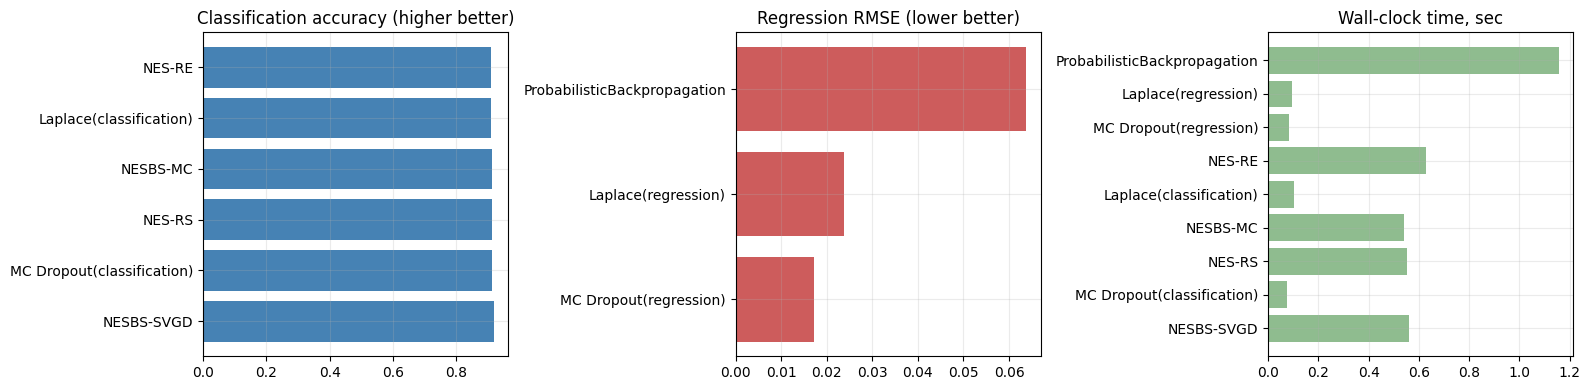

In [17]:
# --- Plots ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].barh(cls_df["method"], cls_df["accuracy"], color="steelblue")
axes[0].set_title("Classification accuracy (higher better)")

axes[1].barh(reg_df["method"], reg_df["rmse"], color="indianred")
axes[1].set_title("Regression RMSE (lower better)")

time_df = pd.concat([
    cls_df[["method", "time_sec"]],
    reg_df[["method", "time_sec"]],
], ignore_index=True)
axes[2].barh(time_df["method"], time_df["time_sec"], color="darkseagreen")
axes[2].set_title("Wall-clock time, sec")

for ax in axes:
    ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()


## Интерпретация

- **Classification**: смотрите `accuracy`, `nll`, `brier`.
- **Regression**: сравнивайте `rmse`.
- `time_sec` — ориентировочная скорость в текущей среде.

Если хотите более надежные выводы, повторите бенчмарк на нескольких `SEED` и усредните.
